In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

# Store Item Demand Forecasting — Time Series Project

**Author:** Zakee Ul Hassan
**Dataset:** [Kaggle: Store Item Demand Forecasting](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data) — 913K rows of daily sales
**Goal:** Forecast next 3 months of daily sales across 50 items × 10 stores. Compare baseline, classical (ARIMA/SARIMA), and ML approaches with walk-forward validation.

In [2]:
df = pd.read_csv('../data/train.csv')
print("Shape:",df.shape)
df.head()


Shape: (913000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
df['date'] = pd.to_datetime(df['date'])
print("Date column dtype:", df['date'].dtype)
print("Date range:", df['date'].min(), "→", df['date'].max())

Date column dtype: datetime64[ns]
Date range: 2013-01-01 00:00:00 → 2017-12-31 00:00:00


In [4]:
print("Total rows:", len(df))
print("Total days:", (df['date'].max() - df['date'].min()).days + 1)
print("Unique stores:", df['store'].nunique())
print("Unique items:", df['item'].nunique())
print("Total combinations:", df['store'].nunique() * df['item'].nunique())
print("Rows per store-item:", len(df) / (df['store'].nunique() * df['item'].nunique()))

Total rows: 913000
Total days: 1826
Unique stores: 10
Unique items: 50
Total combinations: 500
Rows per store-item: 1826.0


In [5]:
print("Sales summary statistics:")
print(df['sales'].describe())
print("\nMissing values:")
print(df.isnull().sum())

Sales summary statistics:
count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64

Missing values:
date     0
store    0
item     0
sales    0
dtype: int64


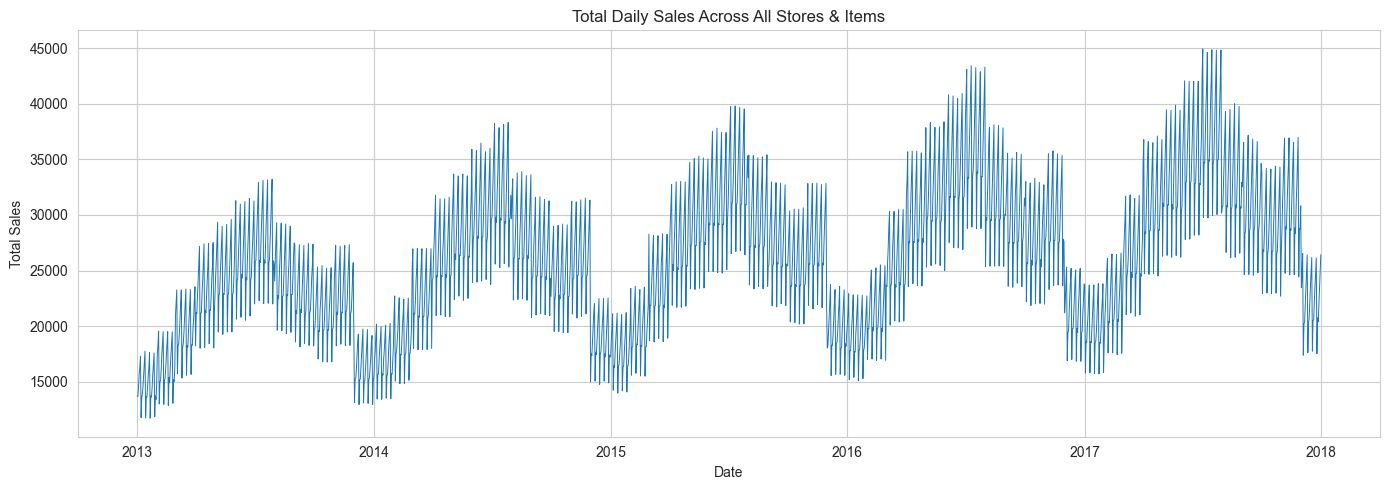

In [6]:
daily_total = df.groupby("date")["sales"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_total['date'], daily_total['sales'], linewidth=0.7)
plt.title('Total Daily Sales Across All Stores & Items')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('../total_daily_sales.png', dpi=100, bbox_inches='tight')
plt.show()

In [7]:
daily_total.head()

,date,sales
0,2013-01-01,13696
1,2013-01-02,13678
2,2013-01-03,14488
3,2013-01-04,15677
4,2013-01-05,16237


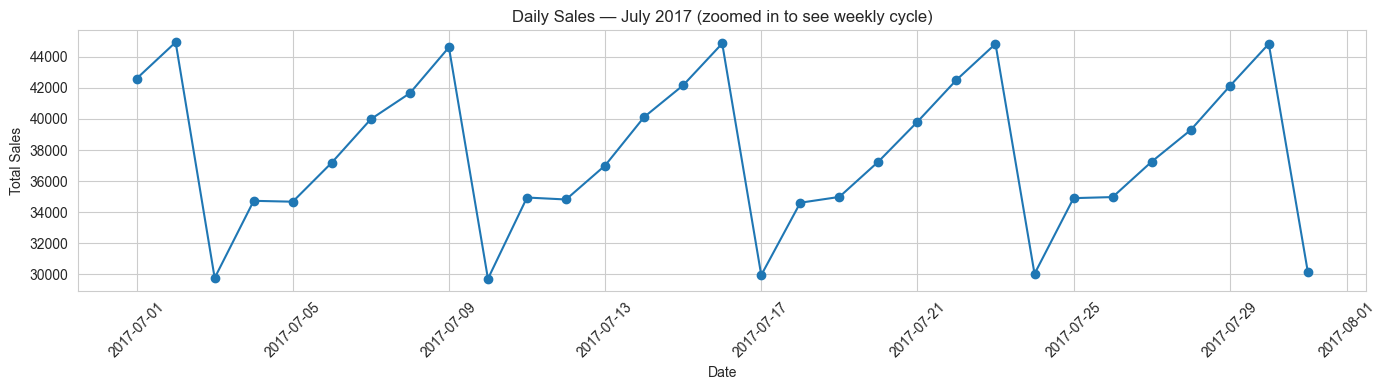

In [8]:
# Zoom in on one month to see weekly pattern
sample_month = daily_total[(daily_total['date'] >= '2017-07-01') & (daily_total['date'] <= '2017-07-31')]

plt.figure(figsize=(14, 4))
plt.plot(sample_month['date'], sample_month['sales'], marker='o', linewidth=1.5)
plt.title('Daily Sales — July 2017 (zoomed in to see weekly cycle)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../weekly_cycle.png', dpi=100, bbox_inches='tight')
plt.show()

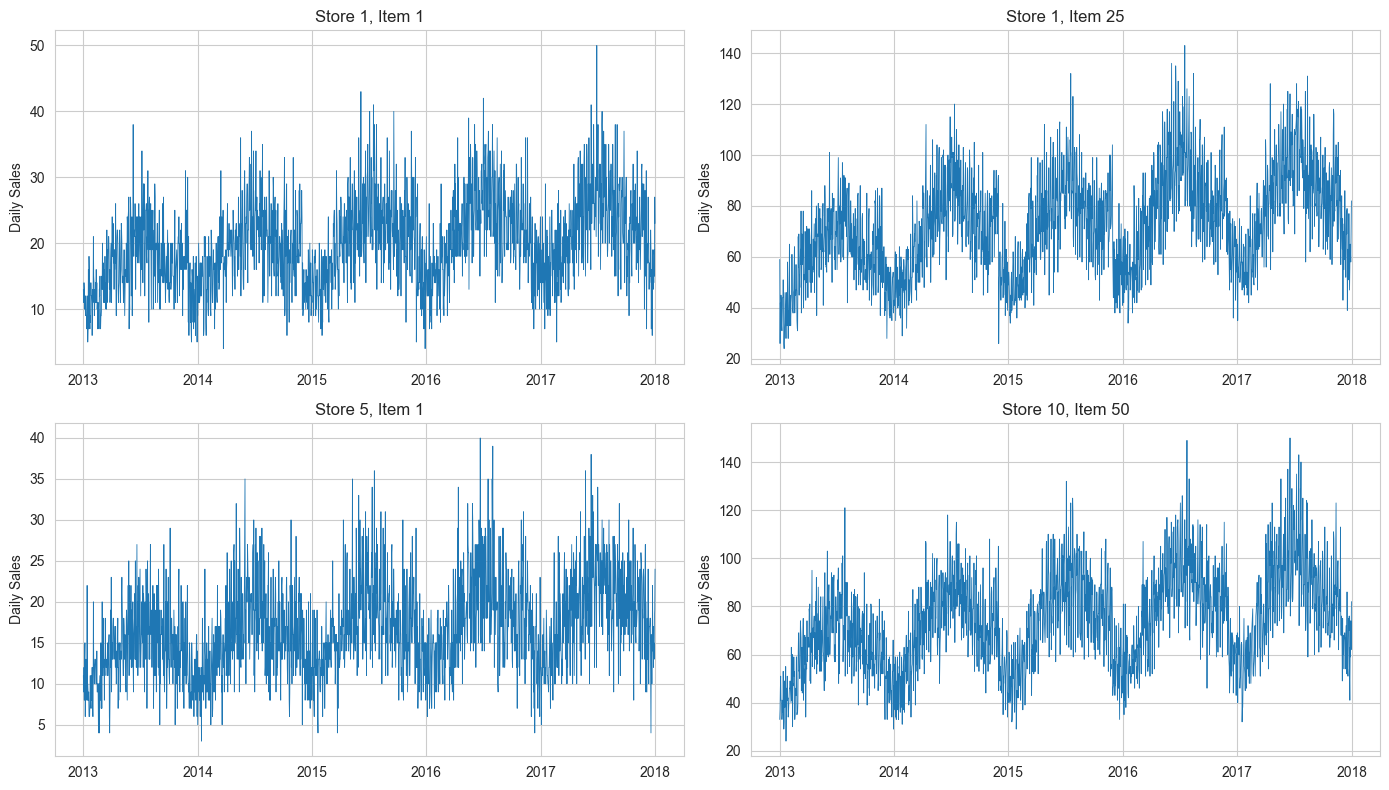

In [9]:
# Pick a few store-item combos to inspect individually
sample_combos = [
    (1, 1),    # store 1, item 1
    (1, 25),   # store 1, item 25 (mid-catalog)
    (5, 1),    # store 5, item 1 (different store, same item as first)
    (10, 50),  # store 10, item 50 (last store, last item)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (store, item) in enumerate(sample_combos):
    series = df[(df['store'] == store) & (df['item'] == item)]
    axes[i].plot(series['date'], series['sales'], linewidth=0.6)
    axes[i].set_title(f'Store {store}, Item {item}')
    axes[i].set_ylabel('Daily Sales')
    
plt.tight_layout()
plt.savefig('../sample_time_series.png', dpi=100, bbox_inches='tight')
plt.show()

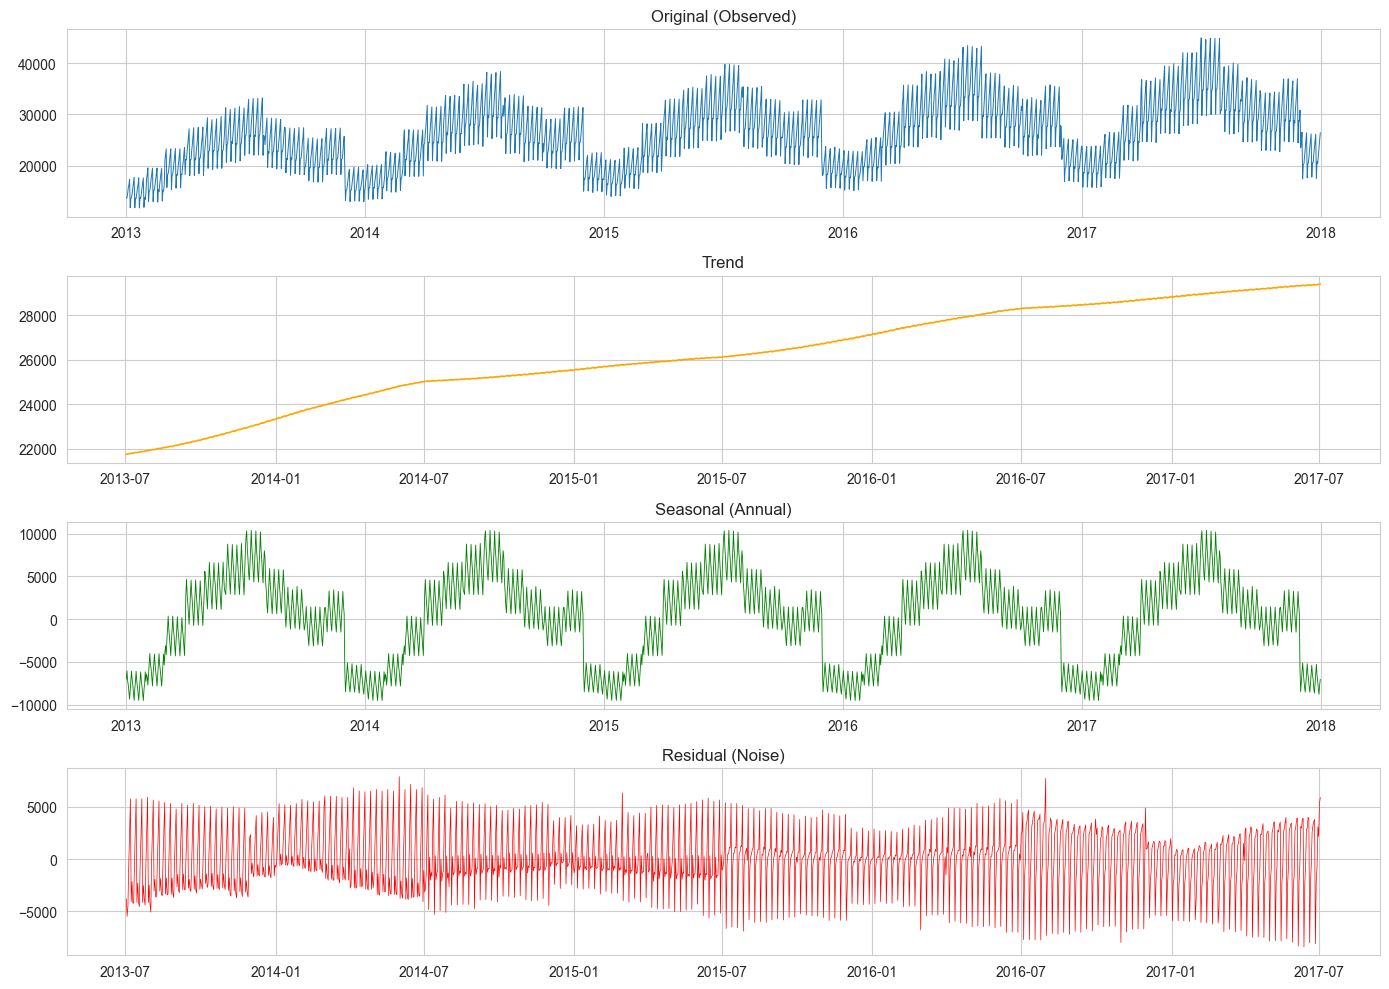

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# We need a clean time series with date as the index
ts = daily_total.set_index('date')['sales']

# Decompose with annual seasonality (period=365 days)
decomp = seasonal_decompose(ts, model='additive', period=365)

# Plot all 4 components: original, trend, seasonal, residual
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(decomp.observed, linewidth=0.7)
axes[0].set_title('Original (Observed)')

axes[1].plot(decomp.trend, color='orange', linewidth=1.2)
axes[1].set_title('Trend')

axes[2].plot(decomp.seasonal, color='green', linewidth=0.6)
axes[2].set_title('Seasonal (Annual)')

axes[3].plot(decomp.resid, color='red', linewidth=0.5)
axes[3].set_title('Residual (Noise)')

plt.tight_layout()
plt.savefig('../decomposition.png', dpi=100, bbox_inches='tight')
plt.show()

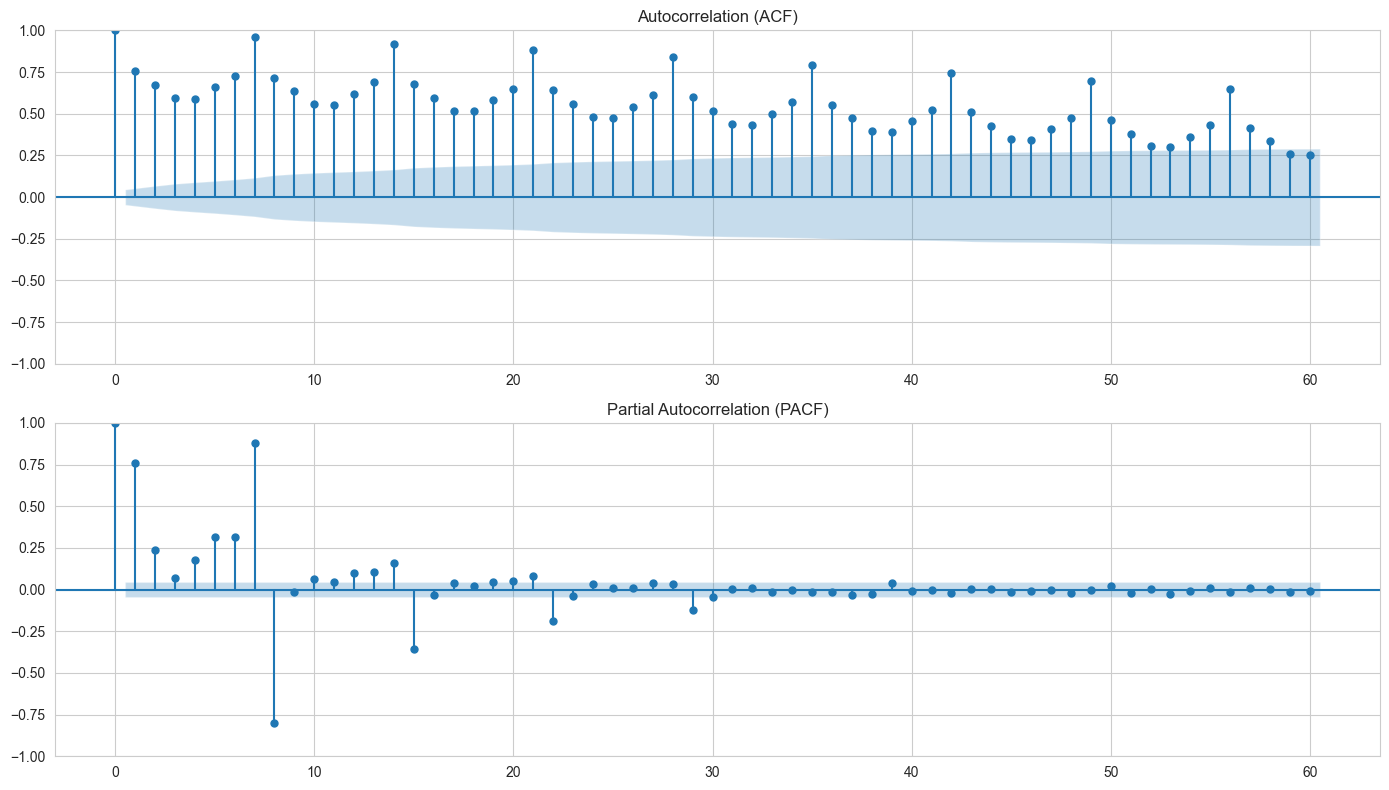

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# We'll plot ACF and PACF on the original total daily sales
# Lags up to 60 days — enough to see daily, weekly, and ~monthly patterns
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts, lags=60, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

plot_pacf(ts, lags=60, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.savefig('../acf_pacf.png', dpi=100, bbox_inches='tight')
plt.show()

### Initial Observations

- **Dataset:** 913,000 rows = 10 stores × 50 items × 1,826 days (5 years, 2013-2017). 500 distinct time series in total.
- **No missing values, no data quality issues** — clean dataset, can move directly to modeling pipeline.
- **Sales statistics:** range 0 to 231, mean ~52, integer-valued count data. Same family as my thesis target (mortality counts) — Poisson-like models will be appropriate.
- **Strong upward trend over 5 years** — sales are growing year-over-year; will need to handle non-stationarity before applying ARIMA.
- **Annual seasonality** with clear summer peaks (June-August). Suggests SARIMA with seasonal_period=365 or seasonal feature engineering.
- **Weekly cycle** visible in zoomed view — weekend peaks, weekday troughs. Will need to capture day-of-week in features for ML models.
- **Sample series are similar in shape, different in scale.** Inspected 4 store-item combos. All show same trend + seasonality + weekly pattern but at different magnitudes (peaks ~40 to ~140). This means a single model architecture should generalize across all 500 series — we won't need clustering or per-segment models.
- **Decomposition confirms 3 components:** clear upward trend, clean repeating annual seasonality, and residual showing weekly cycle (which annual decomposition didn't capture). Total demand has multi-scale seasonality — annual + weekly — both will need to be modeled.
- **ACF/PACF analysis confirms weekly seasonality (period=7).** PACF shows strong direct effects from lags 1-7 with a sharp cutoff at lag 8, indicating the weekly cycle dominates short-term prediction. ACF shows recurring spikes at lags 7, 14, 21, 28 — multi-week structure consistent with the residual pattern from decomposition.
- **Modeling implications:** The weekly cycle is the single strongest predictable signal. SARIMA with seasonal period=7 is a strong baseline candidate. For ML approaches (Random Forest, XGBoost), engineered lag features should include lag_1, lag_7, lag_14 at minimum, plus rolling statistics (7-day and 30-day means).

In [12]:
from statsmodels.tsa.stattools import adfuller, kpss

# Run ADF test on the original total daily sales
adf_result = adfuller(ts.dropna())
print("=== ADF Test (Augmented Dickey-Fuller) ===")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")
print(f"Verdict:       {'STATIONARY' if adf_result[1] < 0.05 else 'NON-STATIONARY'}")
print()

# Run KPSS test
kpss_result = kpss(ts.dropna(), regression='c', nlags='auto')
print("=== KPSS Test ===")
print(f"KPSS Statistic: {kpss_result[0]:.4f}")
print(f"p-value:        {kpss_result[1]:.4f}")
print(f"Verdict:        {'STATIONARY' if kpss_result[1] > 0.05 else 'NON-STATIONARY'}")

=== ADF Test (Augmented Dickey-Fuller) ===
ADF Statistic: -3.0602
p-value:       0.0296
Verdict:       STATIONARY

=== KPSS Test ===
KPSS Statistic: 2.0010
p-value:        0.0100
Verdict:        NON-STATIONARY


C:\Users\NEXGEN\AppData\Local\Temp\ipykernel_15484\4062342713.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(ts.dropna(), regression='c', nlags='auto')


**Stationarity tests confirm non-stationarity.**  ADF (p < 0.05, rejects non-stationary null) and KPSS (p < 0.05, reject stationary null) agree the original series has a trend. ARIMA will need d=1 (one differencing step) to convert to stationary input.

In [13]:
# Split chronologically: train on 2013-2016, test on 2017
train = ts[ts.index < '2017-01-01']
test = ts[ts.index >= '2017-01-01']

print(f"Train: {len(train)} days, from {train.index.min().date()} to {train.index.max().date()}")
print(f"Test:  {len(test)} days, from {test.index.min().date()} to {test.index.max().date()}")

Train: 1461 days, from 2013-01-01 to 2016-12-31
Test:  365 days, from 2017-01-01 to 2017-12-31


Last training day value: 23792


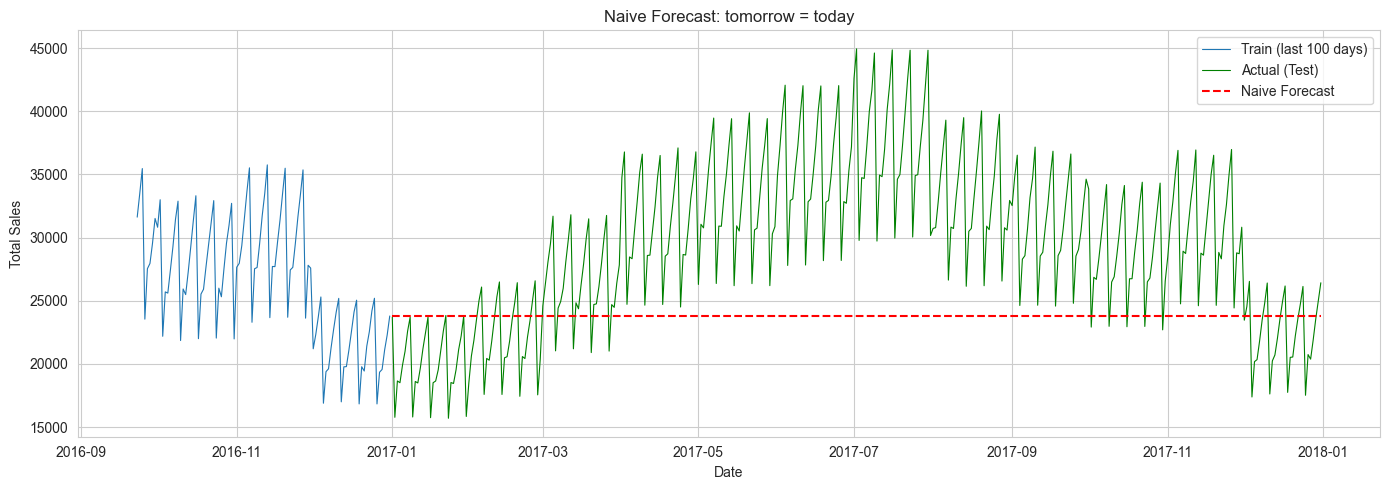

In [14]:
# The single value used for all naive predictions
naive_value = train.iloc[-1]
print(f"Last training day value: {naive_value}")

# Naive forecast: that value repeated for every test day
naive_forecast = pd.Series(
    [naive_value] * len(test),
    index=test.index
)

# Plot it
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)', linewidth=0.8)
plt.plot(test.index, test.values, label='Actual (Test)', linewidth=0.8, color='green')
plt.plot(naive_forecast.index, naive_forecast.values, label='Naive Forecast', linewidth=1.5, color='red', linestyle='--')
plt.title('Naive Forecast: tomorrow = today')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../naive_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

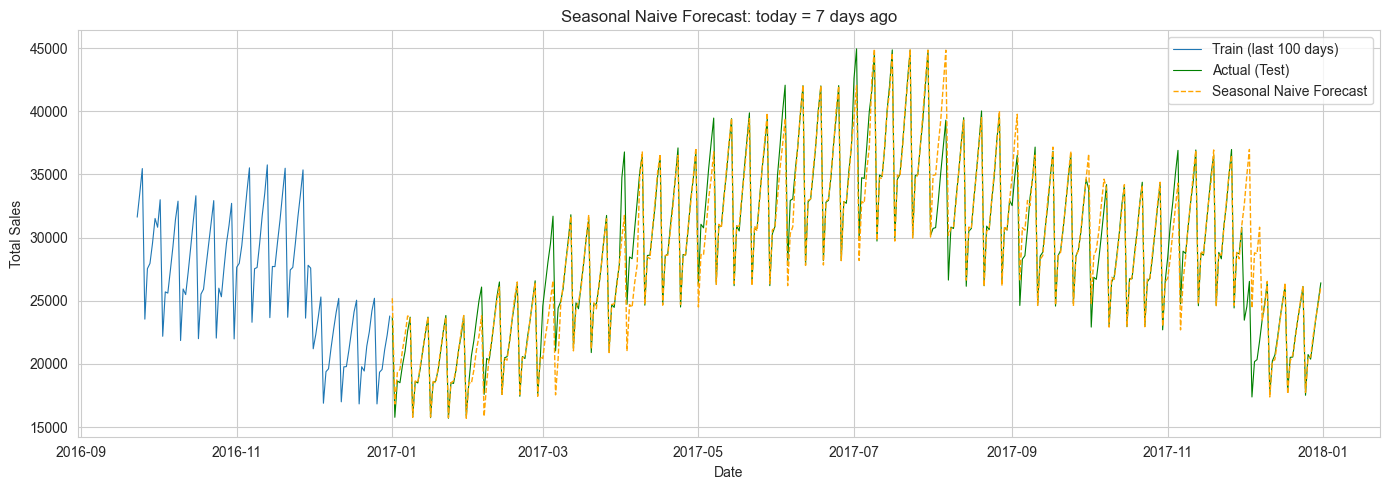

In [15]:
# For each test day, use the value from 7 days earlier
# We need the last 7 training days as the "lookup" for the first week of test
seasonal_naive_forecast = pd.Series(index=test.index, dtype=float)

for i, date in enumerate(test.index):
    # Look back 7 days in the combined train+test history
    lookup_date = date - pd.Timedelta(days=7)
    if lookup_date in train.index:
        seasonal_naive_forecast.iloc[i] = train.loc[lookup_date]
    elif lookup_date in test.index:
        # Use the previously-known test value (from a week ago)
        seasonal_naive_forecast.iloc[i] = test.loc[lookup_date]

# Plot it
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)', linewidth=0.8)
plt.plot(test.index, test.values, label='Actual (Test)', linewidth=0.8, color='green')
plt.plot(seasonal_naive_forecast.index, seasonal_naive_forecast.values, 
         label='Seasonal Naive Forecast', linewidth=1.0, color='orange', linestyle='--')
plt.title('Seasonal Naive Forecast: today = 7 days ago')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../seasonal_naive_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_forecast(actual, predicted, model_name):
    """Compute RMSE, MAE, MAPE for a forecast."""
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    print(f"=== {model_name} ===")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print()
    
    return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

In [17]:
# Evaluate both baselines
results = []
results.append(evaluate_forecast(test, naive_forecast, 'Naive Forecast'))
results.append(evaluate_forecast(test, seasonal_naive_forecast, 'Seasonal Naive Forecast'))

# Build a comparison DataFrame
results_df = pd.DataFrame(results)
print("\nComparison:")
print(results_df.to_string(index=False))

=== Naive Forecast ===
RMSE: 8593.58
MAE:  7019.64
MAPE: 22.15%

=== Seasonal Naive Forecast ===
RMSE: 1868.41
MAE:  902.56
MAPE: 3.25%


Comparison:
                  model        RMSE         MAE      MAPE
         Naive Forecast 8593.583180 7019.638356 22.147774
Seasonal Naive Forecast 1868.413821  902.561644  3.245869


### Baseline Forecasts

**Train/Test Split (chronological):**
- Train: 2013-01-01 to 2016-12-31 (1,461 days, ~80%)
- Test:  2017-01-01 to 2017-12-31 (365 days, ~20%)

**Baseline Results:**

| Model | RMSE | MAE | MAPE |
|---|---|---|---|
| Naive Forecast (today = yesterday) | 8593.58 | 7019.64 | 22.15% |
| Seasonal Naive Forecast (today = same day last week) | **1868.41** | **902.56** | **3.25%** |

**Key Findings:**
- **Seasonal Naive massively outperforms plain Naive** — 4.6× better RMSE, 6.8× better MAPE. Confirms the weekly cycle is the dominant predictable pattern.
- **3.25% MAPE is a high bar for ARIMA to beat.** With seasonal naive already capturing the weekly cycle so cleanly, ARIMA's job is to refine — capture residual structure beyond the weekly pattern (annual seasonality, trend acceleration, day-after-holiday effects).
- **Lesson:** for seasonal time series, simple seasonal-naive is a strong baseline that more complex models must earn improvements over. Always benchmark against it.

Original series — first 5 values:
date
2013-01-01    13696
2013-01-02    13678
2013-01-03    14488
2013-01-04    15677
2013-01-05    16237
Name: sales, dtype: int64

Differenced series — first 5 values:
date
2013-01-02     -18.0
2013-01-03     810.0
2013-01-04    1189.0
2013-01-05     560.0
2013-01-06    1054.0
Name: sales, dtype: float64


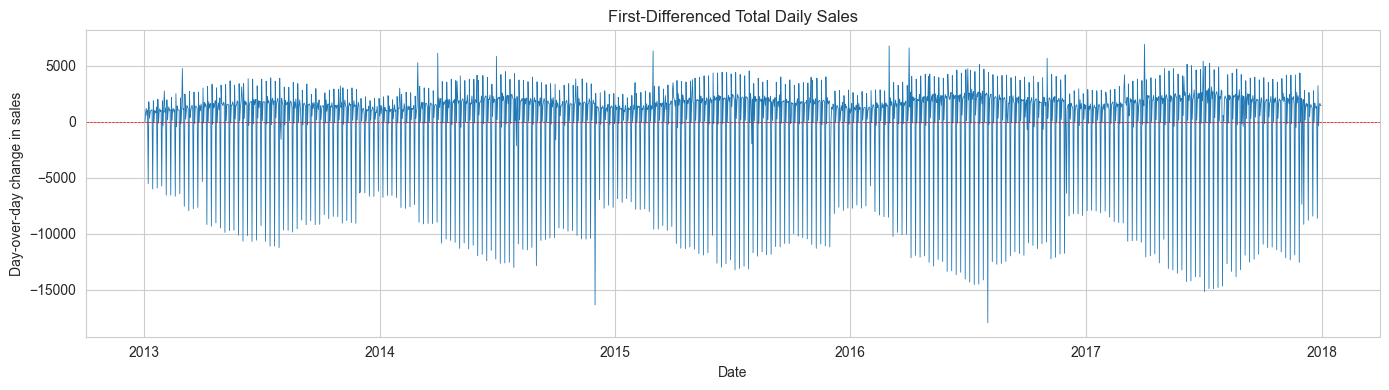

In [18]:
# Difference the series (subtract each value from the previous)
ts_diff = ts.diff().dropna()

print("Original series — first 5 values:")
print(ts.head())
print("\nDifferenced series — first 5 values:")
print(ts_diff.head())

# Plot the differenced series
plt.figure(figsize=(14, 4))
plt.plot(ts_diff.index, ts_diff.values, linewidth=0.6)
plt.axhline(y=0, color='red', linestyle='--', linewidth=0.5)
plt.title('First-Differenced Total Daily Sales')
plt.xlabel('Date')
plt.ylabel('Day-over-day change in sales')
plt.tight_layout()
plt.savefig('../differenced_series.png', dpi=100, bbox_inches='tight')
plt.show()

In [19]:
from statsmodels.tsa.stattools import adfuller, kpss

# ADF test on differenced series
adf_result = adfuller(ts_diff)
print("=== ADF Test (differenced series) ===")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")
print(f"Verdict:       {'STATIONARY' if adf_result[1] < 0.05 else 'NON-STATIONARY'}")
print()

# KPSS test on differenced series
kpss_result = kpss(ts_diff, regression='c', nlags='auto')
print("=== KPSS Test (differenced series) ===")
print(f"KPSS Statistic: {kpss_result[0]:.4f}")
print(f"p-value:        {kpss_result[1]:.4f}")
print(f"Verdict:        {'STATIONARY' if kpss_result[1] > 0.05 else 'NON-STATIONARY'}")

=== ADF Test (differenced series) ===
ADF Statistic: -8.9190
p-value:       0.0000
Verdict:       STATIONARY

=== KPSS Test (differenced series) ===
KPSS Statistic: 0.0511
p-value:        0.1000
Verdict:        STATIONARY


C:\Users\NEXGEN\AppData\Local\Temp\ipykernel_15484\3265883062.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(ts_diff, regression='c', nlags='auto')


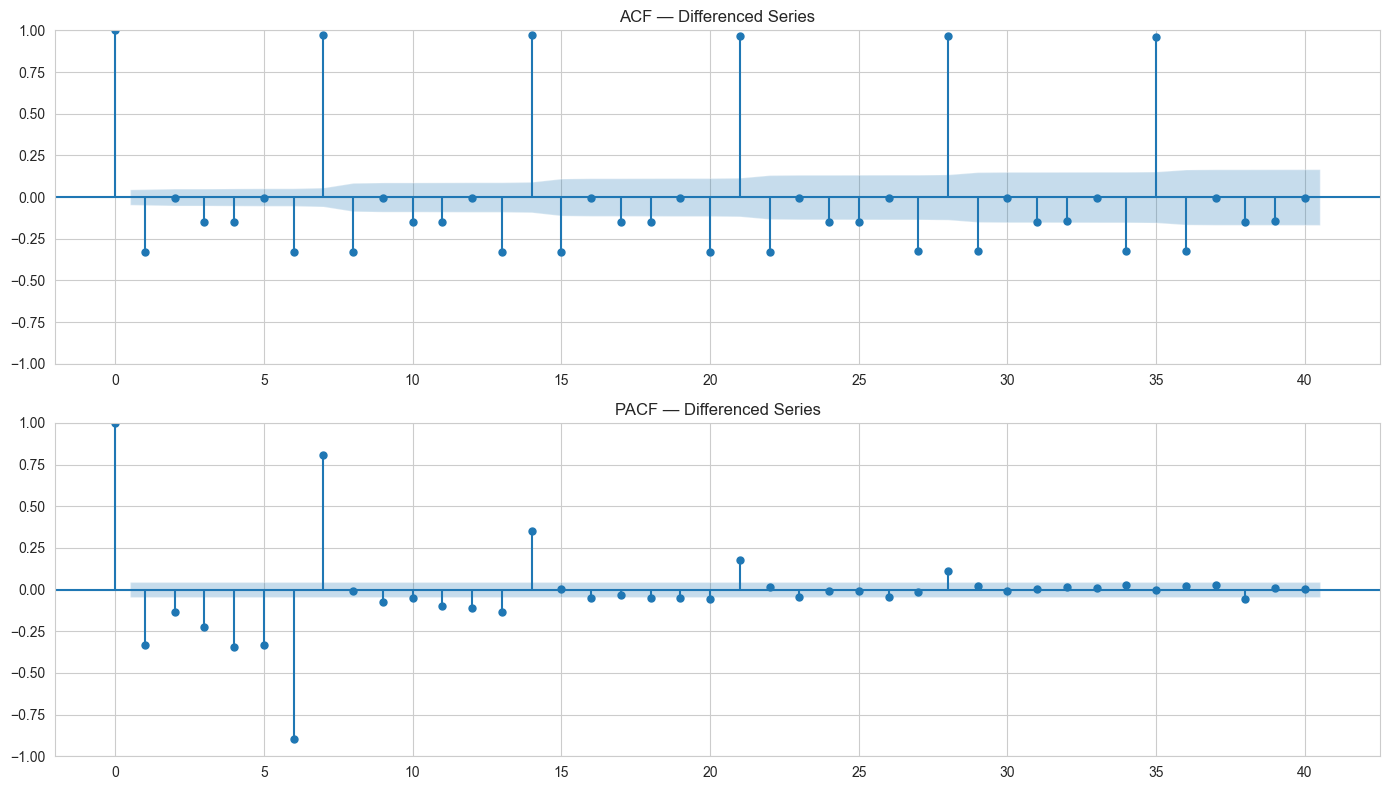

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts_diff, lags=40, ax=axes[0])
axes[0].set_title('ACF — Differenced Series')

plot_pacf(ts_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF — Differenced Series')

plt.tight_layout()
plt.savefig('../acf_pacf_differenced.png', dpi=100, bbox_inches='tight')
plt.show()

In [21]:
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(1, 1, 1) on the training data
arima_model = ARIMA(train, order=(1, 1, 1))
arima_fitted = arima_model.fit()

print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1461
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -14014.271
Date:                Wed, 06 May 2026   AIC                          28034.542
Time:                        14:35:59   BIC                          28050.401
Sample:                    01-01-2013   HQIC                         28040.458
                         - 12-31-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2194      0.034      6.465      0.000       0.153       0.286
ma.L1         -0.8956      0.017    -52.619      0.000      -0.929      -0.862
sigma2      1.272e+07   1.36e-09   9.34e+15      0.0

=== ARIMA(1,1,1) ===
RMSE: 10039.96
MAE:  8344.24
MAPE: 25.84%



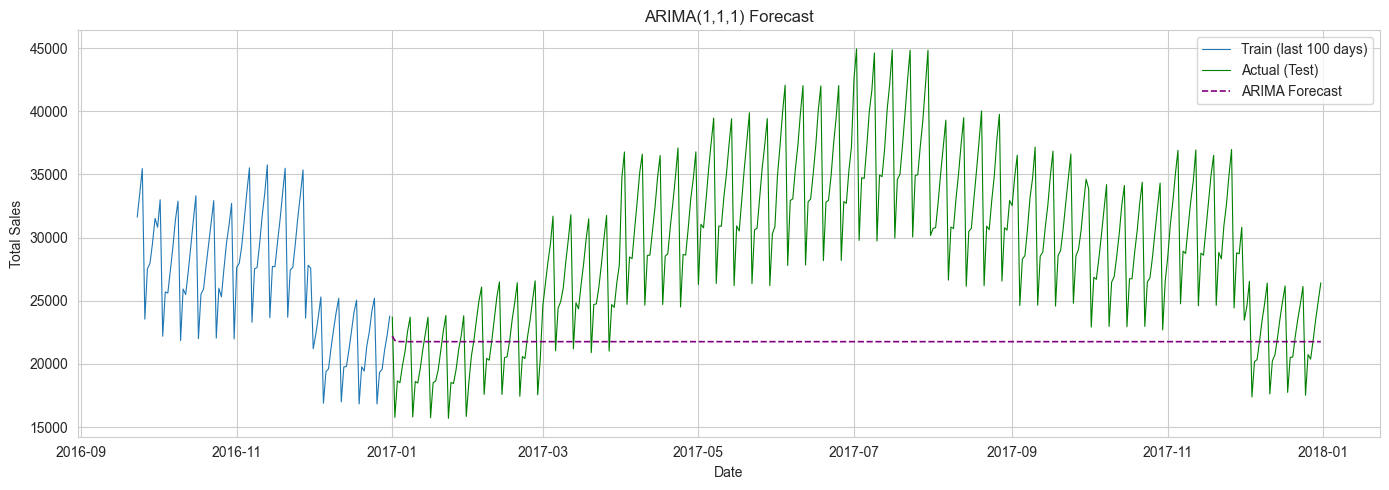

In [22]:
# Forecast 365 days ahead (matching test set length)
arima_forecast = arima_fitted.forecast(steps=len(test))

# Evaluate using the same function from yesterday
arima_metrics = evaluate_forecast(test, arima_forecast, 'ARIMA(1,1,1)')
results.append(arima_metrics)

# Plot the forecast
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)', linewidth=0.8)
plt.plot(test.index, test.values, label='Actual (Test)', linewidth=0.8, color='green')
plt.plot(test.index, arima_forecast.values, label='ARIMA Forecast', linewidth=1.2, color='purple', linestyle='--')
plt.title('ARIMA(1,1,1) Forecast')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../arima_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA — adds seasonal_order=(P, D, Q, s) on top of regular order
sarima_model = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7)
)
sarima_fitted = sarima_model.fit(disp=False)

print("SARIMA fitting complete.")
print(f"AIC: {sarima_fitted.aic:.2f}")

SARIMA fitting complete.
AIC: 23448.01


=== SARIMA(1,1,1)(1,1,1,7) ===
RMSE: 8979.64
MAE:  7593.77
MAPE: 23.62%



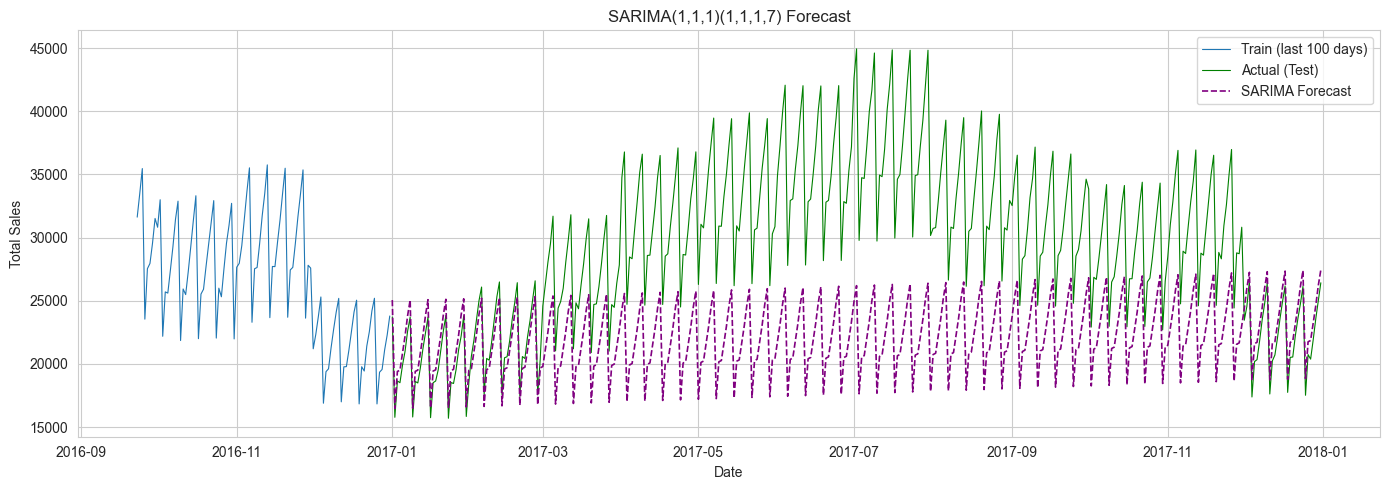

In [24]:
# Forecast 365 days ahead
sarima_forecast = sarima_fitted.forecast(steps=len(test))

# Evaluate
sarima_metrics = evaluate_forecast(test, sarima_forecast, 'SARIMA(1,1,1)(1,1,1,7)')
results.append(sarima_metrics)

# Plot forecast
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)', linewidth=0.8)
plt.plot(test.index, test.values, label='Actual (Test)', linewidth=0.8, color='green')
plt.plot(test.index, sarima_forecast.values, label='SARIMA Forecast', linewidth=1.2, color='purple', linestyle='--')
plt.title('SARIMA(1,1,1)(1,1,1,7) Forecast')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../sarima_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

In [25]:
# Look at the actual forecast values and test values side by side
print("First 14 days of forecasts vs actuals:")
print()

comparison = pd.DataFrame({
    'date':            test.index[:14],
    'actual':          test.values[:14].astype(int),
    'naive':           naive_forecast.values[:14].astype(int),
    'seasonal_naive':  seasonal_naive_forecast.values[:14].astype(int),
    'arima':           arima_forecast.values[:14].astype(int),
    'sarima':          sarima_forecast.values[:14].astype(int)
})
print(comparison.to_string(index=False))

print()
print("Forecast value ranges:")
print(f"  Test actual:    min={test.min():.0f},  max={test.max():.0f},  mean={test.mean():.0f}")
print(f"  ARIMA forecast: min={arima_forecast.min():.0f},  max={arima_forecast.max():.0f},  mean={arima_forecast.mean():.0f}")
print(f"  SARIMA forecast: min={sarima_forecast.min():.0f},  max={sarima_forecast.max():.0f},  mean={sarima_forecast.mean():.0f}")

First 14 days of forecasts vs actuals:

      date  actual  naive  seasonal_naive  arima  sarima
2017-01-01   23709  23792           25195  22205   25052
2017-01-02   15772  23792           16831  21857   16471
2017-01-03   18650  23792           19341  21781   19402
2017-01-04   18510  23792           19560  21764   19491
2017-01-05   19895  23792           21111  21760   20843
2017-01-06   20994  23792           22296  21760   22204
2017-01-07   22591  23792           23792  21759   23813
2017-01-08   23700  23792           23709  21759   25061
2017-01-09   15797  23792           15772  21759   16498
2017-01-10   18608  23792           18650  21759   19406
2017-01-11   18491  23792           18510  21759   19506
2017-01-12   19684  23792           19895  21759   20873
2017-01-13   21186  23792           20994  21759   22226
2017-01-14   22434  23792           22591  21759   23830

Forecast value ranges:
  Test actual:    min=15697,  max=44936,  mean=29408
  ARIMA forecast: min=21760,

In [26]:
import time

# Walk-forward forecast: refit weekly, predict 7 days ahead
history = list(train.values)  # start with all training data
walk_forward_predictions = []
step_size = 7

start_time = time.time()
n_steps = len(test) // step_size

print(f"Walk-forward: {n_steps} weeks to forecast ({len(test)} test days, {step_size}-day steps)")
print(f"Starting at {time.strftime('%H:%M:%S')}...")
print()

for i in range(n_steps):
    # Refit SARIMA on current history
    model = SARIMAX(history, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
    fitted = model.fit(disp=False)
    
    # Forecast next 7 days
    forecast = fitted.forecast(steps=step_size)
    walk_forward_predictions.extend(forecast)
    
    # Observe the actual next 7 days and add them to history
    actual_next = test.values[i*step_size : (i+1)*step_size]
    history.extend(actual_next)
    
    # Print progress every 10 weeks
    if (i + 1) % 10 == 0:
        elapsed = time.time() - start_time
        print(f"  Week {i+1}/{n_steps}  |  elapsed: {elapsed:.0f}s")

elapsed_total = time.time() - start_time
print(f"\nDone. Total time: {elapsed_total:.0f}s")

# Convert to a pandas Series with proper date index
wf_forecast = pd.Series(
    walk_forward_predictions,
    index=test.index[:len(walk_forward_predictions)]
)

# Evaluate
test_aligned = test.iloc[:len(wf_forecast)]
wf_metrics = evaluate_forecast(test_aligned, wf_forecast, 'SARIMA Walk-Forward')
results.append(wf_metrics)

Walk-forward: 52 weeks to forecast (365 test days, 7-day steps)
Starting at 14:52:28...

  Week 10/52  |  elapsed: 34s
  Week 20/52  |  elapsed: 62s
  Week 30/52  |  elapsed: 93s
  Week 40/52  |  elapsed: 125s
  Week 50/52  |  elapsed: 159s

Done. Total time: 166s
=== SARIMA Walk-Forward ===
RMSE: 1315.68
MAE:  696.06
MAPE: 2.48%



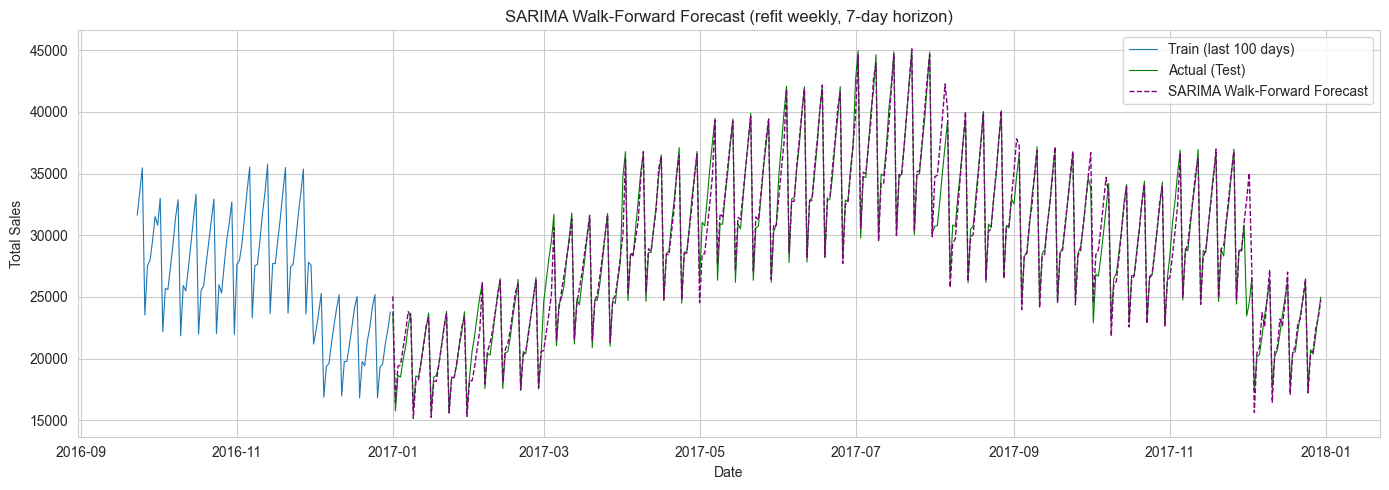

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)', linewidth=0.8)
plt.plot(test_aligned.index, test_aligned.values, label='Actual (Test)', linewidth=0.8, color='green')
plt.plot(wf_forecast.index, wf_forecast.values, label='SARIMA Walk-Forward Forecast', linewidth=1.0, color='purple', linestyle='--')
plt.title('SARIMA Walk-Forward Forecast (refit weekly, 7-day horizon)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../sarima_walk_forward.png', dpi=100, bbox_inches='tight')
plt.show()

### ARIMA, SARIMA, and Walk-Forward Forecasting

**Models Trained:**
| Model | RMSE | MAE | MAPE |
|---|---|---|---|
| Naive (today=yesterday) | 8593.58 | 7019.64 | 22.15% |
| Seasonal Naive (today=last week) | 1868.41 | 902.56 | 3.25% |
| ARIMA(1,1,1) single-shot | 10039.96 | 8344.24 | 25.84% |
| SARIMA(1,1,1)(1,1,1,7) single-shot | 8979.64 | 7593.77 | 23.62% |
| **SARIMA(1,1,1)(1,1,1,7) walk-forward** | **1315.68** | **696.06** | **2.48%** |

**Key Finding — Deployment Matters:**
Single-shot ARIMA and SARIMA underperformed on the 365-day horizon, drifting away from the rising trend. With walk-forward refitting (retrain weekly, forecast 7 days ahead), SARIMA dropped to 2.48% MAPE — beating seasonal naive cleanly. Same model, same parameters, but realistic deployment.

**Lesson:** long-horizon classical forecasting requires deployment-realistic evaluation. A model that "looks bad" on a 365-day blind forecast may shine in production where it sees recent data continuously.

**Next:** Random Forest and XGBoost with engineered lag features. Tree-based ML models can naturally use lag features as inputs and may find non-linear patterns that classical methods miss.